In [1]:
 ! nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [2]:
!pip3 install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [3]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
if torch.cuda.is_available():
  #
  print("CUDA is available. GPU will be used.")
  device = torch.device('cuda')
  print(device, torch.cuda.get_device_name(0))
else:
  #
  print("CUDA is not available. CPU will be used.")
  device = torch.device('cpu')

CUDA is available. GPU will be used.
cuda Tesla T4


In [5]:
# 0. Link colab với Drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
!pwd

/content


In [7]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu124
0.20.1+cu124


In [8]:
# Download TorchVision repo to use some files from references/detection
!git clone https://github.com/pytorch/vision.git
%cd vision
!git checkout v0.20.1

!cp references/detection/utils.py ../
!cp references/detection/transforms.py ../
!cp references/detection/coco_eval.py ../
!cp references/detection/engine.py ../
!cp references/detection/coco_utils.py ../

Cloning into 'vision'...
remote: Enumerating objects: 609360, done.
remote: Counting objects: 100% (787/787), done.
remote: Compressing objects: 100% (735/735), done.
remote: Total 609360 (delta 687), reused 87 (delta 47), pack-reused 608573 (from 4)
Receiving objects: 100% (609360/609360), 1.14 GiB | 17.95 MiB/s, done.
Resolving deltas: 100% (569792/569792), done.
/content/vision
Note: switching to 'v0.20.1'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 3ac97aa912 Update version.txt to 0.20.1 (#8694)


In [9]:
!pwd
%cd ..
!pwd

/content/vision
/content
/content


In [10]:
# Define transformations
class CocoTransform:
    def __call__(self, image, target):
        #image = F.to_tensor(image)  # Convert PIL image to tensor
        return image, target

In [11]:
from collections import defaultdict

# Define transformations
class CocoTransform2:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        print(f"image: {image}")
        print(f"targer: {target}")
        print(f"type of targer: {type(target)}")
        target_dict = defaultdict(list)
        for tar in target:
          target_dict[tar["image_id"]].append(tar)
        target_dict = dict(target_dict)
        print(f"target_dict: {target_dict}")
        print(f"type of target_dict: {type(target_dict)}")
        return image, target_dict

In [12]:
from collections import defaultdict
import torch

# Define transformations
class CocoTransform1:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        #print(f"image: {image}")
        #print(f"targer: {target}")
        #print(f"type of targer: {type(target)}")
        target_dict = defaultdict(list)
        for tar in target:
          target_dict[tar["image_id"]].append(tar)
        target_dict = dict(target_dict)
        # Convert list values to tensors within target_dict
        for k, v in target_dict.items():
            for i in range(len(v)):
                for key in ['boxes', 'area', 'iscrowd', 'labels']:  # Adjust keys as needed
                    if key in v[i] and isinstance(v[i][key], list):
                        v[i][key] = torch.tensor(v[i][key])
        #print(f"target_dict: {target_dict}")
        #print(f"type of target_dict: {type(target_dict)}")
        return image, target_dict

In [13]:
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        # Convert target to the expected format
        target = {
            "boxes": torch.as_tensor([obj["bbox"] for obj in target], dtype=torch.float32),
            "labels": torch.as_tensor([obj["category_id"] for obj in target], dtype=torch.int64),
            "image_id": torch.tensor([target[0]["image_id"] if target else 0]), # Add image_id
            "area": torch.as_tensor([obj["area"] for obj in target], dtype=torch.float32),
            "iscrowd": torch.as_tensor([obj["iscrowd"] for obj in target], dtype=torch.int64),
        }
        return image, target

In [14]:
class CocoTransform5:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        # Convert target to the expected format
        target = {
            "boxes": torch.as_tensor([obj["bbox"] for obj in target], dtype=torch.float32),
            "labels": torch.as_tensor([obj["category_id"] for obj in target], dtype=torch.int64),
            "image_id": torch.tensor([target[0]["image_id"] if target else 0]), # Add image_id
            "area": torch.as_tensor([obj["area"] for obj in target], dtype=torch.float32),
            "iscrowd": torch.as_tensor([obj["iscrowd"] for obj in target], dtype=torch.int64),
        }

        # Filter out invalid boxes # Add this section
        valid_boxes_mask = (target["boxes"][:, 2] > target["boxes"][:, 0]) & (target["boxes"][:, 3] > target["boxes"][:, 1])  # Check for positive width and height
        target["boxes"] = target["boxes"][valid_boxes_mask]
        target["labels"] = target["labels"][valid_boxes_mask]
        target["area"] = target["area"][valid_boxes_mask]
        target["iscrowd"] = target["iscrowd"][valid_boxes_mask]

        return image, target

In [15]:
class CocoTransform6:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        # Convert target to the expected format
        target = {
            "boxes": torch.as_tensor([obj["bbox"] for obj in target], dtype=torch.float32),
            "labels": torch.as_tensor([obj["category_id"] for obj in target], dtype=torch.int64),
            "image_id": torch.tensor([target[0]["image_id"] if target else 0]), # Add image_id
            "area": torch.as_tensor([obj["area"] for obj in target], dtype=torch.float32),
            "iscrowd": torch.as_tensor([obj["iscrowd"] for obj in target], dtype=torch.int64),
        }

        # Filter out invalid boxes # Add this section
        valid_boxes_mask = (target["boxes"][:, 2] > target["boxes"][:, 0]) & (target["boxes"][:, 3] > target["boxes"][:, 1])  # Check for positive width and height
        target["boxes"] = target["boxes"][valid_boxes_mask]
        target["labels"] = target["labels"][valid_boxes_mask]
        target["area"] = target["area"][valid_boxes_mask]
        target["iscrowd"] = target["iscrowd"][valid_boxes_mask]

        # Ensure image_id is an integer
        target["image_id"] = target["image_id"].item() # Change to .item()

        return image, target

In [16]:
#from engine import train_one_epoch, evaluate

from engine import train_one_epoch, evaluate
import utils
import transforms as T

def get_transform(train):
  transforms = []
  # converts the image, a PIL image, into a PyTorch Tensor
  transforms.append(T.ToTensor())
  if train:
      # during training, randomly flip the training images
      # and ground-truth for data augmentation
      transforms.append(T.RandomHorizontalFlip(0.5))
  return T.Compose(transforms)

In [17]:
# Dataset class
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform6()
    )

# Load datasets
train_dataset = get_coco_dataset(
    img_dir="/content/gdrive/MyDrive/Faster_RCNN/CHV_Dataset_COCO_v3/train",
    ann_file="/content/gdrive/MyDrive/Faster_RCNN/CHV_Dataset_COCO_v3/train/anno/_annotations.coco.json"
)


val_dataset = get_coco_dataset(
    img_dir="/content/gdrive/MyDrive/Faster_RCNN/CHV_Dataset_COCO_v3/val",
    ann_file="/content/gdrive/MyDrive/Faster_RCNN/CHV_Dataset_COCO_v3/val/anno/_annotations.coco.json"
)



# DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
#val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=6.57s)
creating index...
index created!
loading annotations into memory...
Done (t=0.96s)
creating index...
index created!


In [19]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [20]:
# Initialize the model
num_classes = 7 # Background + chair, human, table
model = get_model(num_classes)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 193MB/s]


In [21]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
#device = torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [22]:
!pwd


/content


In [ ]:
import os


save_dir = "/content/gdrive/MyDrive/Faster_RCNN/KQ2"
os.makedirs(save_dir, exist_ok=True)  # Tạo thư mục nếu chưa tồn tại
# Training loop
num_epochs = 1

for epoch in range(num_epochs):
  # train for one epoch, printing every 10 iterations
  train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=10)
  # update the learning rate
  lr_scheduler.step()
  model_path = os.path.join(save_dir, f"fasterrcnn_resnet50_epoch_{epoch + 1}.pth")
  torch.save(model.state_dict(), model_path)
  print(f"Model saved: {model_path}")
  # evaluate on the test dataset
  evaluate(model, val_loader, device=device)

/content/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/267]  eta: 0:22:23  lr: 0.000024  loss: 0.2796 (0.2796)  loss_classifier: 0.0826 (0.0826)  loss_box_reg: 0.0736 (0.0736)  loss_objectness: 0.0809 (0.0809)  loss_rpn_box_reg: 0.0425 (0.0425)  time: 5.0316  data: 3.5473  max mem: 4704
Epoch: [0]  [ 10/267]  eta: 0:19:25  lr: 0.000212  loss: 0.2662 (0.2391)  loss_classifier: 0.0492 (0.0508)  loss_box_reg: 0.0454 (0.0395)  loss_objectness: 0.0522 (0.0604)  loss_rpn_box_reg: 0.0425 (0.0884)  time: 4.5369  data: 3.2053  max mem: 7660
Epoch: [0]  [ 20/267]  eta: 0:18:36  lr: 0.000399  loss: 0.1790 (0.2504)  loss_classifier: 0.0342 (0.0482)  loss_box_reg: 0.0247 (0.0387)  loss_objectness: 0.0416 (0.0700)  loss_rpn_box_reg: 0.0244 (0.0935)  time: 4.4944  data: 3.1935  max mem: 7667
Epoch: [0]  [ 30/267]  eta: 0:17:35  lr: 0.000587  loss: 0.2275 (0.2779)  loss_classifier: 0.0507 (0.0534)  loss_box_reg: 0.0456 (0.0448)  loss_objectness: 0.0502 (0.0856)  loss_rpn_box_reg: 0.0681 (0.0941)  time: 4.4093  data: 3.1421  max mem: 7672


AssertionError: Results do not correspond to current coco set

In [ ]:
!cp /usr/local/lib/python3.11/dist-packages/pycocotools/cocoeval.py ./cocoeval.py
!cp /usr/local/lib/python3.11/dist-packages/pycocotools/mask.py ./mask.py

In [23]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from engine import evaluate
from PIL import Image
import utils
from torch.utils.data import DataLoader, Dataset


# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Initialize the model
num_classes = 7  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


#val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=utils.collate_fn)

# Load the trained model
model = get_model(num_classes)
model.load_state_dict(torch.load("/content/gdrive/MyDrive/Faster_RCNN/Ketqua3/fasterrcnn_resnet50_epoch_12.pth"))
model.to(device)
#model.eval()  # Set the model to evaluation mode

print("🔥 Chương trình đang chạy...")
print(f"Model type: {type(model)}")
print(f"Validation loader type: {type(val_loader)}")
print(f"Device: {device}")
  #
evaluate(model, val_loader, device)




<ipython-input-23-69b3bcdd13de>:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/gdrive/MyDrive/Faster_RCNN/Ketqua3/fasterrcnn_re

🔥 Chương trình đang chạy...
Model type: <class 'torchvision.models.detection.faster_rcnn.FasterRCNN'>
Validation loader type: <class 'torch.utils.data.dataloader.DataLoader'>
Device: cuda
Test:  [ 0/32]  eta: 0:03:20  model_time: 1.8636 (1.8636)  evaluator_time: 0.0159 (0.0159)  time: 6.2739  data: 4.3885  max mem: 2906
Test:  [31/32]  eta: 0:00:03  model_time: 0.5517 (0.6322)  evaluator_time: 0.0067 (0.0073)  time: 3.8091  data: 3.1992  max mem: 3231
Test: Total time: 0:02:06 (3.9447 s / it)
Averaged stats: model_time: 0.5517 (0.6322)  evaluator_time: 0.0067 (0.0073)
Accumulating evaluation results...
DONE (t=0.08s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.488
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.856
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.498
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.217
 Average Precision  (AP) @[ IoU=0.50:

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-25-41d0e16a669a>:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrust

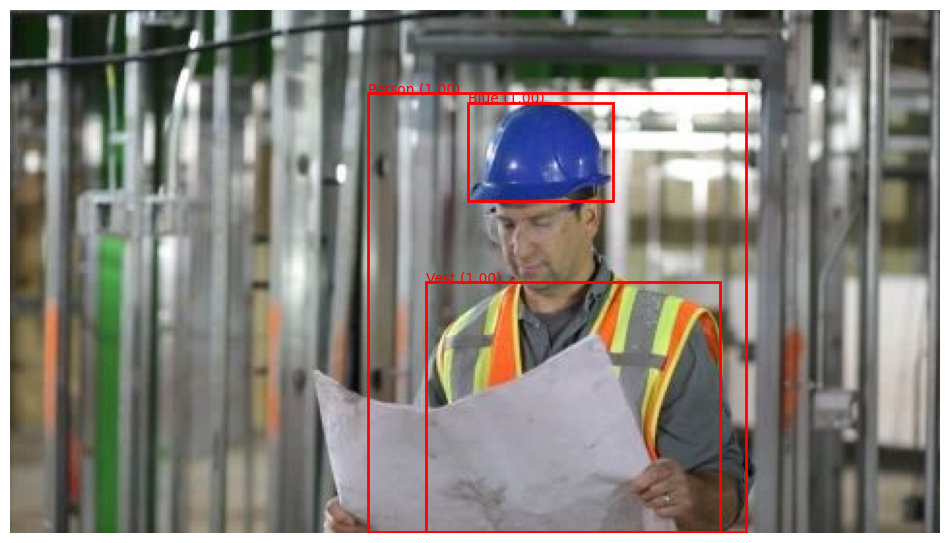

In [25]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# Initialize the model
num_classes = 7  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# Load the trained model
model = get_model(num_classes)
model.load_state_dict(torch.load("/content/gdrive/MyDrive/Faster_RCNN/Ketqua3/fasterrcnn_resnet50_epoch_12.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode


def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Open image
    image_tensor = F.to_tensor(image).unsqueeze(0)  # Convert image to tensor and add batch dimension
    return image_tensor.to(device)



# Load the unseen image
image_path = "/content/ppe_0003.jpg"
image_tensor = prepare_image(image_path)

with torch.no_grad():  # Disable gradient computation for inference
    prediction = model(image_tensor)

# `prediction` contains:
# - boxes: predicted bounding boxes
# - labels: predicted class labels
# - scores: predicted scores for each box (confidence level)
COCO_CLASSES = {0: "Background", 1: "Person", 2: "Vest", 3: "Blue", 4: "Red", 5: "White", 6: "Yellow"}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")

# Draw bounding boxes with the correct class names and increase image size
def draw_boxes(image, prediction, fig_size=(10, 10)):
    boxes = prediction[0]['boxes'].cpu().numpy()  # Get predicted bounding boxes
    labels = prediction[0]['labels'].cpu().numpy()  # Get predicted labels
    scores = prediction[0]['scores'].cpu().numpy()  # Get predicted scores

    # Set a threshold for showing boxes (e.g., score > 0.5)
    threshold = 0.5

    # Set up the figure size to control the image size
    plt.figure(figsize=fig_size)  # Adjust the figure size here

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)  # Get the class name
            plt.imshow(image)  # Display the image
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                              linewidth=2, edgecolor='r', facecolor='none'))
            plt.text(x_min, y_min, f"{class_name} ({score:.2f})", color='r')

    plt.axis('off')  # Turn off axis
    plt.show()

# Display the image with bounding boxes and correct labels
draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))  # Example of increased size